# ChordCutter Bot


## Dataset

[Music Bench](https://huggingface.co/datasets/amaai-lab/MusicBench)

## Idea

<strong>Input</strong>: audio file

<strong>Output</strong>: chord sheet

1. Input audio file
2. Audio file gets split into segments (ex: 10s)
3. Each segment gets passed into the NN. Outputs the chord progression and the timestamp
4. Pass the same segment into another NN that generates the lyrics and timestamps
5. Overlay the chords and lyrics based on the timestamps

### Components

1. Audio to chords NN
2. Audio to lyrics NN
3. Chord sheet assembler
4. Data preprocessor (ex: .mp3 to .wav?)


### Data Loading


In [1]:
# Libraries
import os
import torch
import requests
import tarfile
import librosa
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datasets import load_dataset

/Users/seannguyen/GitHub/ChordCutterBot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("amaai-lab/MusicBench")
ds

DatasetDict({
    train: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 52768
    })
    test: Dataset({
        features: ['dataset', 'location', 'main_caption', 'alt_caption', 'prompt_aug', 'prompt_ch', 'prompt_bt', 'prompt_bpm', 'prompt_key', 'beats', 'bpm', 'chords', 'chords_time', 'key', 'keyprob', 'is_audioset_eval_mcaps'],
        num_rows: 800
    })
})

In [3]:
train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

train_df
# test_df

# TODO: remove np.nan from chords list

,dataset,location,main_caption,alt_caption,prompt_aug,prompt_ch,prompt_bt,prompt_bpm,prompt_key,beats,bpm,chords,chords_time,key,keyprob,is_audioset_eval_mcaps
0,MusicBench,data_aug2/-0SdAVK79lg_1.wav,This mellow instrumental track showcases a dom...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 112.0.,The key of this song is E major.,"[[0.37212133669135816, 0.9070457581851855, 1.4...",112.0,[E],[0.5400400339790407],"[E, major]",[0.8934084177017212],False
1,MusicBench,data_aug2/-0SdAVK79lg_2.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2658142022146419, 0.6479221178981897, 1.04...",157.0,[E],[0.4485947212378337],"[E, major]",[0.8934084177017212],False
2,MusicBench,data_aug2/-0SdAVK79lg_3.wav,This laid-back instrumental track is perfect f...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat counts to 4.,The bpm is 151.0.,The key of this song is E major.,"[[0.2754422138603508, 0.6713903962846051, 1.08...",151.0,[E],[0.3861310098244245],"[E, major]",[0.8934084177017212],False
3,MusicBench,data_aug2/-0SdAVK79lg_4.wav,This is a relaxing song that features an elect...,This song features an electric guitar as the m...,,The chord progression in this song is E.,The beat is 4.,The song is played at the pace of Vivace.,This song is in the key of E major.,"[[0.2801938173601484, 0.6829724298153618, 1.10...",148.0,[E],[0.33809850513698275],"[E, major]",[0.8934084177017212],False
4,MusicBench,data_aug2/-0SdAVK79lg_5.wav,This relaxing song is perfect for a coffee sho...,This song features an electric guitar as the m...,,The chord sequence is C#.,The time signature is 4/4.,This song goes at 130.0 beats per minute.,This song is in the key of C# major.,"[[0.32, 0.78, 1.26, 1.74, 2.2, 2.66, 3.12, 3.5...",130.0,[C#],[0.33809850513698275],"[C#, major]",[0.8934084177017212],False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52763,MusicBench,data/zir3uL14ijM.wav,This mellow tune is led by a passionate male v...,The low quality recording features a passionat...,,"The chord progression in this song is E, F#m7,...",The beat is 3.,The bpm is 92.0.,This song is in the key of E major.,"[[0.02, 0.68, 1.38, 2.0, 2.66, 3.3, 3.96, 4.58...",92.0,"[E, F#m7, F#m7b5, E/B]","[0.464399092, 1.30031746, 3.90095238, 6.315827...","[E, major]",[0.8000931739807129],False
52764,MusicBench,data/zjZV0tvur2I.wav,"This song, in the key of G minor and with a te...",The low quality recording features a widely sp...,,The chord sequence is Ab7.,The beat counts to 2.,The tempo of this song is 127.0 beats per minute.,This song is in the key of G minor.,"[[0.28, 0.76, 1.22, 1.72, 2.2, 2.66, 3.16, 3.6...",127.0,[Ab7],[1.30031746],"[G, minor]",[0.7355943918228149],False
52765,MusicBench,data/zjsWFvUkh7M.wav,This Pop Rock song is led by a lively male voc...,A male vocalist sings this energetic song. The...,,"The chord sequence is D, Gm, Daug.",The beat is 3.,This song goes at 110.0 beats per minute.,The key of this song is D minor.,"[[0.02, 0.54, 1.06, 1.58, 2.12, 2.64, 3.18, 3....",110.0,"[D, Gm, Daug]","[0.557278911, 3.622312925, 8.266303854]","[D, minor]",[0.7975711822509766],True
52766,MusicBench,data/zqbHYVH6Wqo.wav,This devotional and spirited instrumental song...,The song is an instrumental. The tempo is medi...,,The chord sequence is F.,The beat is 2.,This song is played in Presto.,The key is F major.,"[[0.28, 0.6, 0.94, 1.28, 1.64, 1.98, 2.32, 2.6...",177.0,[F],[0.464399092],"[F, major]",[0.8479340076446533],False


### Chord Exploration


In [4]:
# Takes in a Series (chords column) and gives a set of unique chords
def get_chord_set(chords: pd.Series) -> set:
    return set(chords.apply(list).explode().unique())

# Returns a list of root chords; simplifies slash chords if necessary
def get_root_chords(chords) -> list:
    return map(lambda x: x.split('/')[0] if is_slash_chord(x) else x, chords)

# Filter for slash chords
def is_slash_chord(chord) -> bool:
    return chord and isinstance(chord, str) and "/" in chord

In [5]:
# Chords exploration
chords = train_df['chords']

# Set of all chords
chords_set = set(get_chord_set(chords))

# Set of all slash chords (ex: C/E)
slash_chords = set(filter(is_slash_chord, chords_set))

# Set of root chords of the slash chords (ex: C from C/E)
root_slash = set(get_root_chords(slash_chords))

# Set of (all chords - slash chords) U (root chords)
root_chords = (chords_set - slash_chords).union(root_slash)

print(f"All Chords:\tsize={len(chords_set)}, {chords_set}")
print(f"Slash Chords:\tsize={len(slash_chords)}, {slash_chords}")
print(f"Root Slash:\tsize={len(root_slash)}, {root_slash}")
print(f"Root Chords:\tsize={len(root_chords)}, {root_chords}")
# The number of root chords is the total number of chords minus the number of slash chords
# (there are no roots from slash chords that do not appear in the set of non-slash chords)

All Chords:	size=292, {'A/B', 'Ebm', 'A#', 'Dm7b5/C', 'Faug', 'Abdim', 'Dm7b5', 'G#6', 'G#m7b5', 'Ab6', 'D#maj7', 'Fm', 'C#/G#', 'Daug', 'A/C#', 'Eb/G', 'Bdim', 'Gb6', 'Eb7/G', 'G#m7', 'Cdim', 'Bbm6', 'F#7/A#', 'F#dim', 'Ebm6', 'A#/F', 'D#/C#', 'F/C', 'C#/D#', 'G6', 'C#m7', 'Abm7b5', 'Bm', 'Ebm7', 'F', 'B/Db', 'Em7b5/D', 'F#m', 'Dbm7b5/B', 'F#m7b5/E', 'Fdim', 'D/A', 'D#/G', 'A7/C#', 'Bmaj7', 'C7/E', 'A6', 'G/D', 'C#maj7', 'Db6', 'Dbmaj7', 'Cm7b5', 'Bm7', 'Eb', 'D#', 'Ebaug', 'G#maj7', 'Abaug', 'Cm7', 'Gbmaj7', 'F#m7b5', 'A#/C', 'C#7/F', 'D7', 'Db/B', 'B6', 'C#7', 'A#aug', 'Am7b5', 'D#/A#', 'Ab/C', 'F/A', 'Dm', 'Ebm7b5', 'E7/G#', 'C#m7b5', 'C#dim', 'E', 'C#/F', 'Bbaug', 'E/D', 'C/D', 'D#m7b5/C#', 'A/G', 'G#aug', 'N', 'Bm7b5/A', 'D#m7b5/Db', 'Eb6', 'Gaug', 'Dm6', 'F/Eb', 'B/C#', 'Gb/Ab', 'Gdim', 'Gm7', 'Gb7', 'Edim', 'Cm', 'Db7', 'Em7', 'Ab/Bb', 'E/F#', 'G#/F#', 'Bbm7', 'D/E', 'Cm7b5/Bb', 'D#m6', 'F7/A', 'Bb/D', 'Gbm6', 'Adim', 'Em7b5', 'D#m7b5', 'A#7/D', 'Db/D#', 'Db7/F', 'F6', 'F/G', '

In [6]:
num_chord_classes = len(root_chords)
print(num_chord_classes)

172


### Audio Analysis Exploration


In [7]:
def open_audio_file(location='', num=-1):
    ''' 
    Gets the tar file online without reading everything into memory. Iterates through response one file at a time.
    Only considers files (and currently .wav files). Can be used to get a specific file, though this is achieved
    by iterating over every item in the decompressed tar file. Can also be used to get a specific number of files.

    Input
    - location: the filepath (as provided by the "Location" column in the dataset) to retrieve (note: current implementation is very inefficient). Default is the empty string, which will output all files
    - num: the number of files to retrieve, from the beginning. Default is -1, which will output all the files

    Output
    - None
    '''
    url = 'https://huggingface.co/datasets/amaai-lab/MusicBench/resolve/main/MusicBench.tar.gz'
    response = requests.get(url, stream=True)
    print("response received!")
    print(response, '\n')
    retrieved_count = 0
    
    if response.status_code == 200:
        # open tar file as a stream
        with tarfile.open(fileobj=response.raw, mode='r|gz') as tar:
            print("opened tar file!")

            for member in tar:
                # only care about files
                # if location is given, only get that file; otherwise get all files
                if member.isfile() and (member.name == f"datashare/{location}" or not location):
                    file = tar.extractfile(member)
                    print("Type:", type(file))
                    print("File:", file)
                    print(f"File name: {member.name}")

                    file = tar.extractfile(member)
                    print("Extracted file:", file, '\n')

                    # read this file into memory
                    file_bytes = BytesIO(file.read())

                    # only get audio files
                    if member.name.endswith('.wav'):
                        audio_data, sr = librosa.load(file_bytes, sr=None)

                        # metadata
                        print("-----METADATA-----")
                        print(f"Audio length: {len(audio_data)} samples, Sample Rate: {sr}")
                        print(type(audio_data), audio_data.shape)
                        print("audio_data element:", audio_data[0])

                        # sound amplitude
                        plt.plot(audio_data)
                        plt.show()

                        # Mel-frequency cepstral coefficients
                        mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=13)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(mfccs, sr=sr, x_axis='time')
                        plt.colorbar(label='MFCC')
                        plt.title('MFCCs')
                        plt.show()
                        print("MFCCs:", mfccs.shape)

                        # chroma feature extraction
                        chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr)
                        print("Chroma Shape:", chroma.shape)
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', cmap='coolwarm', sr=sr)
                        plt.colorbar(label='Intensity')
                        plt.title('Chroma Feature Representation')
                        plt.xlabel('Time (seconds)')
                        plt.ylabel('Pitch Class')
                        plt.show()

                        # harmonic-percussive separation
                        harmonic, percussive = librosa.effects.hpss(y=audio_data)

                        plt.figure(figsize=(10, 4))
                        plt.plot(harmonic, label="Harmonic")
                        plt.plot(percussive, label="Percussive")
                        plt.legend()
                        plt.title("Harmonic & Percussive Separation")
                        plt.show()

                        # Constant-Q Transform (CQT)
                        cqt = librosa.cqt(y=audio_data, sr=sr)
                        cqt_db = librosa.amplitude_to_db(abs(cqt))
                        plt.figure(figsize=(10, 4))
                        librosa.display.specshow(cqt_db, sr=sr, x_axis='time', y_axis='cqt_note', cmap='coolwarm')
                        plt.colorbar(label='dB')
                        plt.title('Constant-Q Transform (CQT)')
                        plt.show()

                    file.close()
                    if location:  # stop after finding requested file
                        break
                    else:
                        retrieved_count += 1
                        if retrieved_count == num:
                            break
    else:
        print(f"Failed to download the file: {response.status_code}")

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


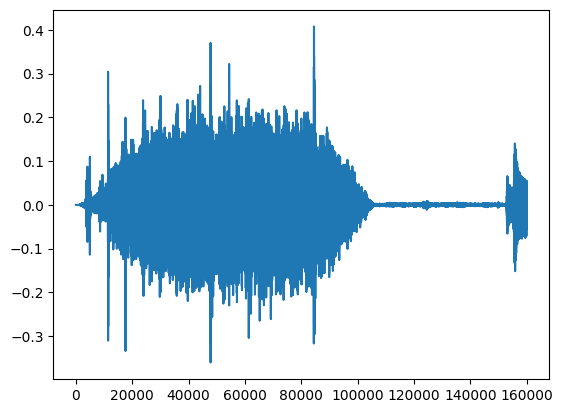

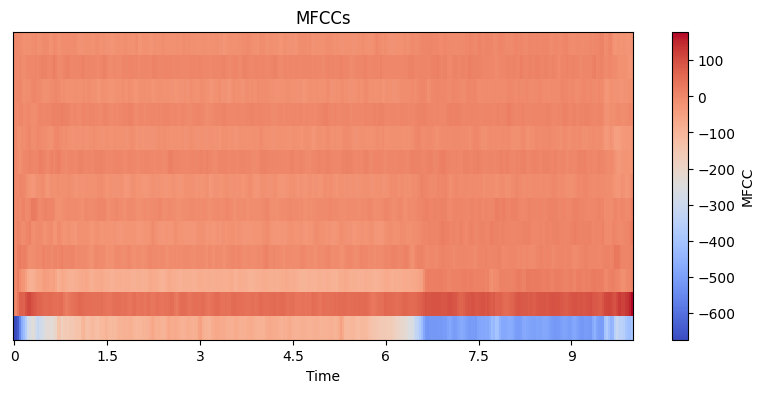

MFCCs: (13, 313)
Chroma Shape: (12, 313)


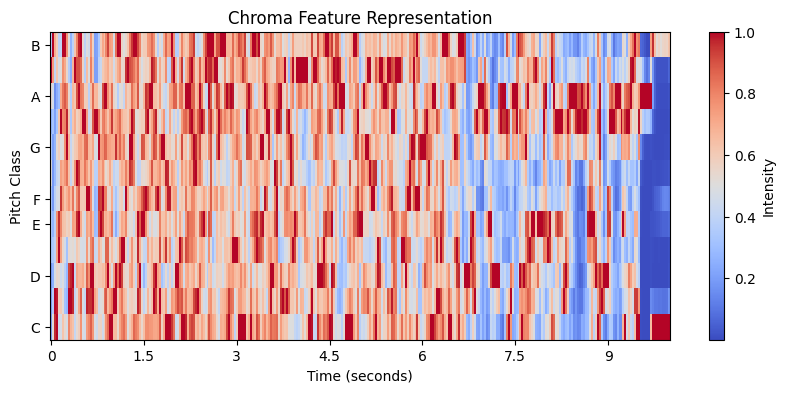

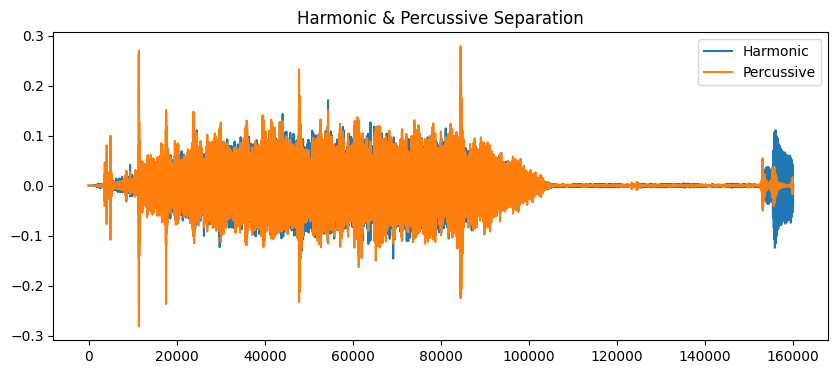

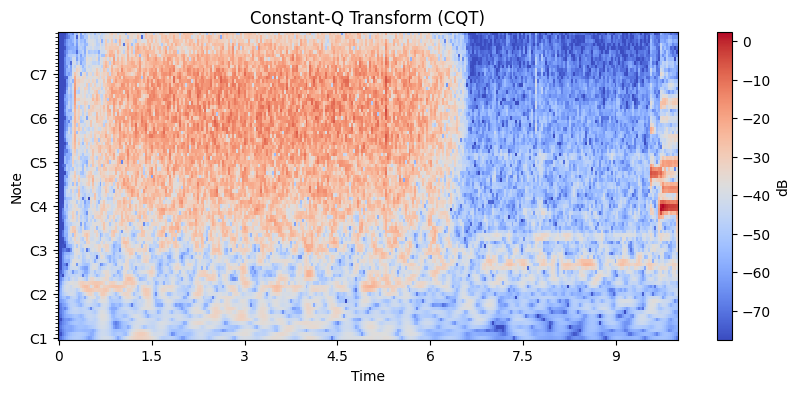

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'>
File name: datashare/data_aug2/4a1a-lmDVaY_11.wav
Extracted file: <ExFileObject name='datashare/data_aug2/4a1a-lmDVaY_11.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0024597168


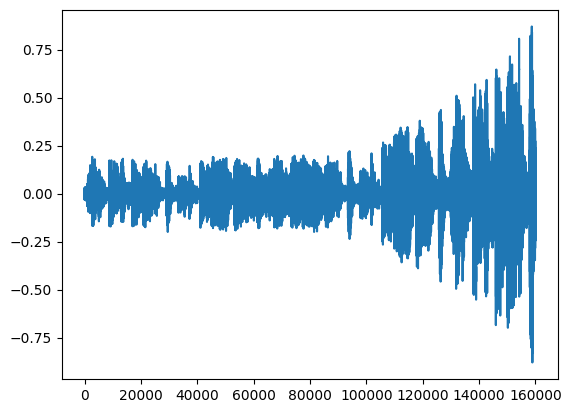

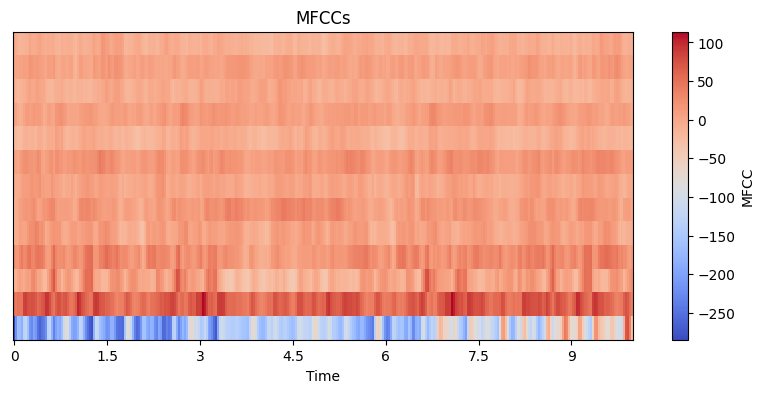

MFCCs: (13, 313)
Chroma Shape: (12, 313)


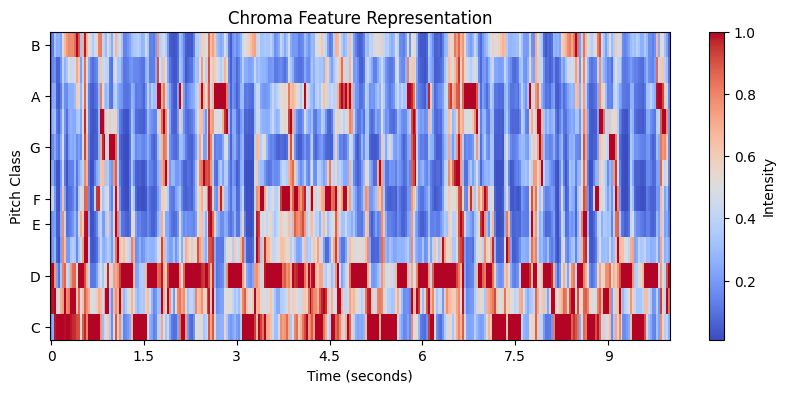

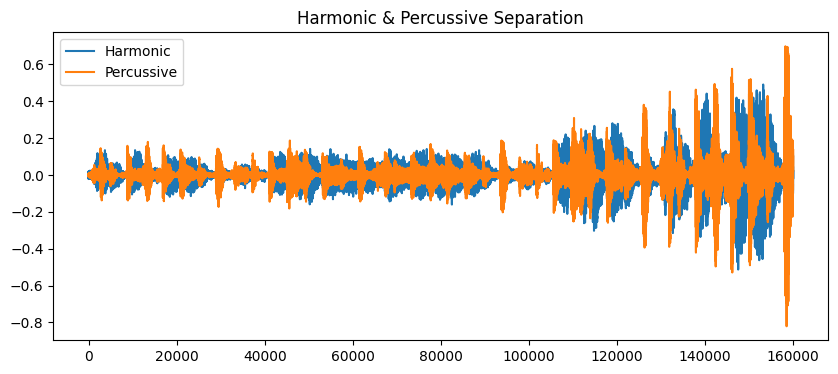

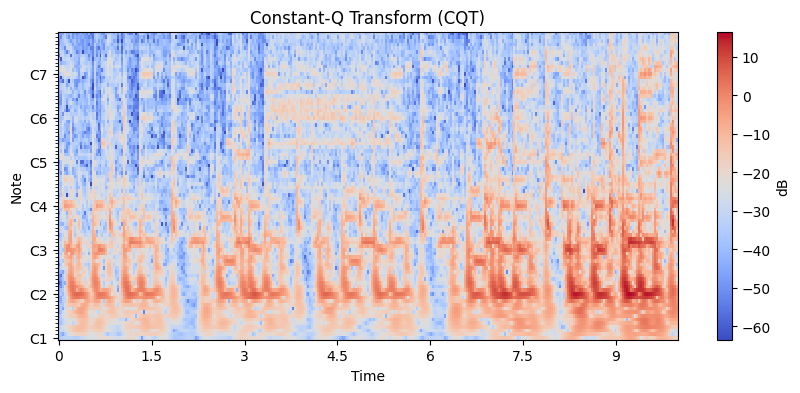

Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'>
File name: datashare/data_aug2/rE7S4nLrThs_5.wav
Extracted file: <ExFileObject name='datashare/data_aug2/rE7S4nLrThs_5.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: -0.031066895


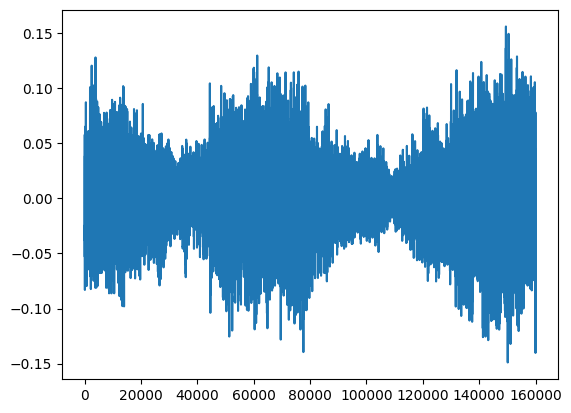

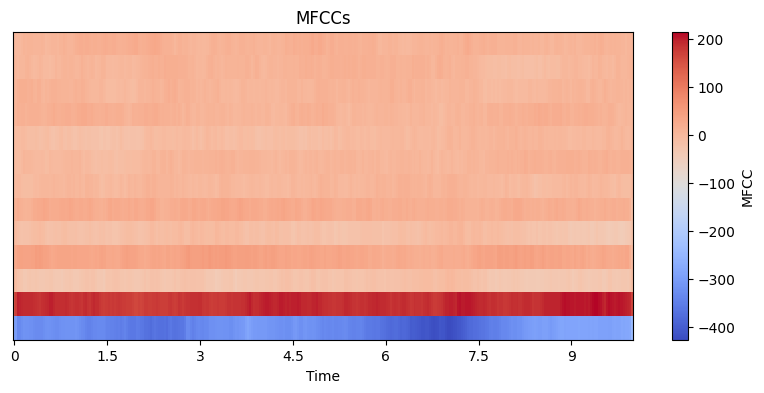

MFCCs: (13, 313)
Chroma Shape: (12, 313)


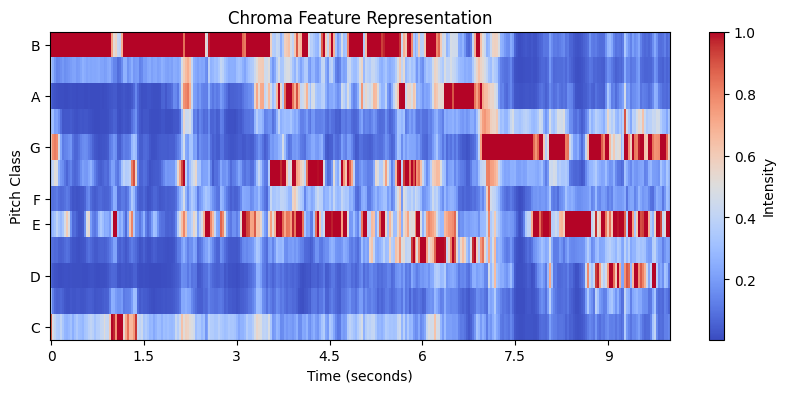

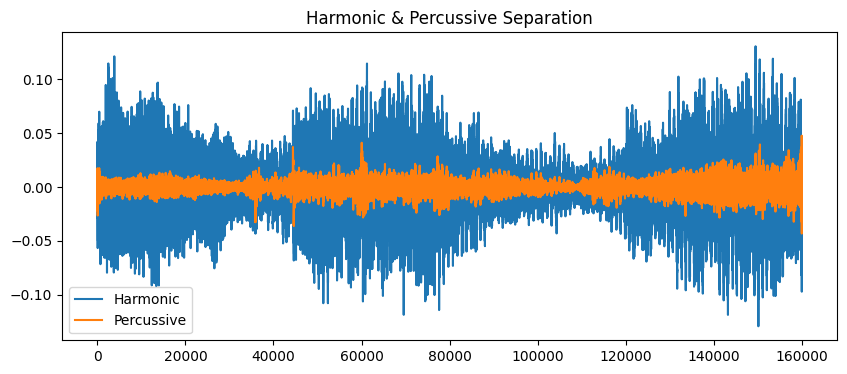

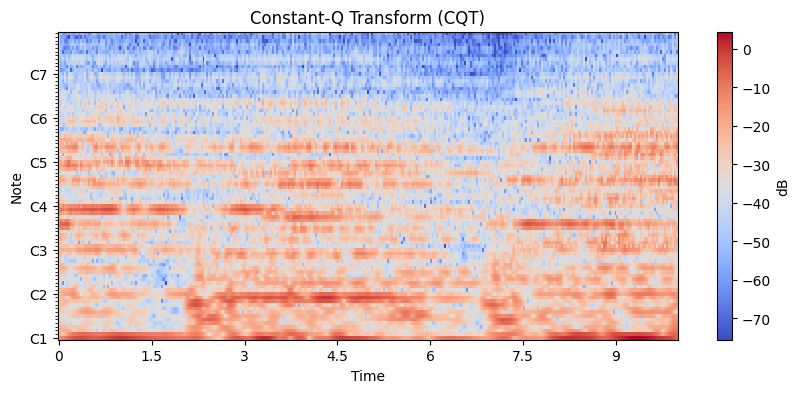

In [8]:
# get specific number of audio files
open_audio_file(num=3)

response received!
<Response [200]> 

opened tar file!
Type: <class 'tarfile.ExFileObject'>
File: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'>
File name: datashare/data_aug2/u3yOMK8SuRI_1.wav
Extracted file: <ExFileObject name='datashare/data_aug2/u3yOMK8SuRI_1.wav'> 

-----METADATA-----
Audio length: 160000 samples, Sample Rate: 16000
<class 'numpy.ndarray'> (160000,)
audio_data element: 0.0


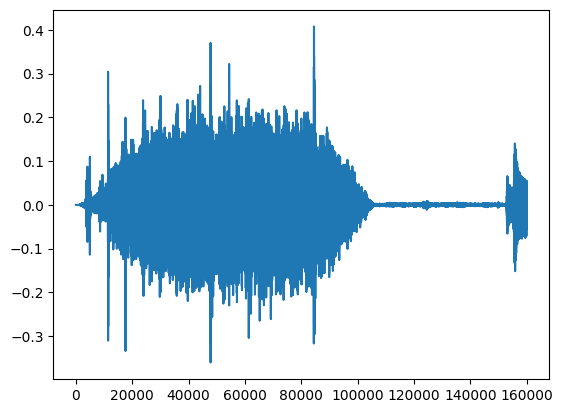

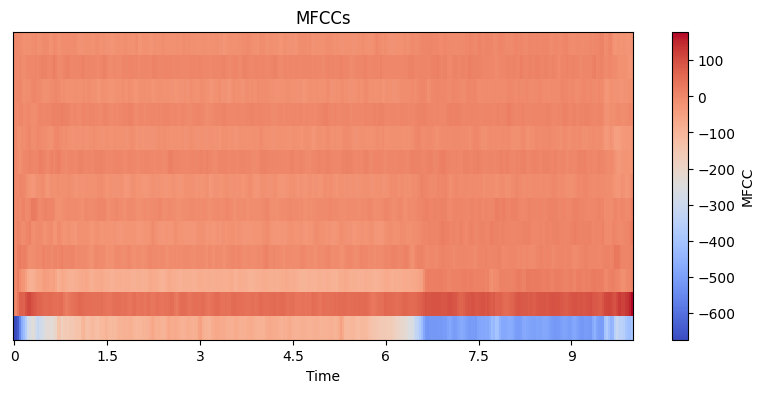

MFCCs: (13, 313)
Chroma Shape: (12, 313)


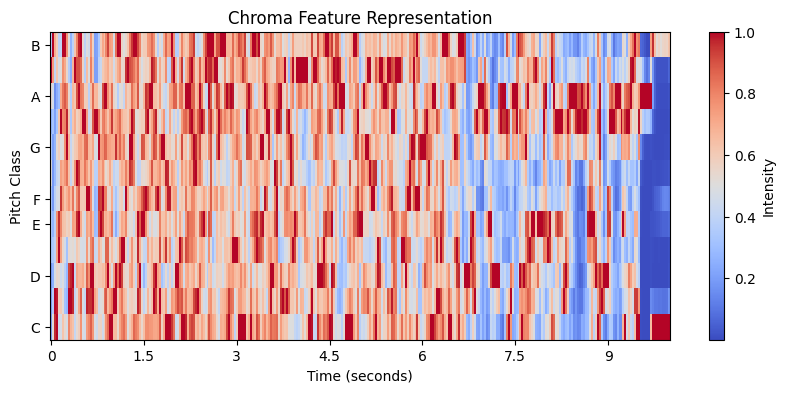

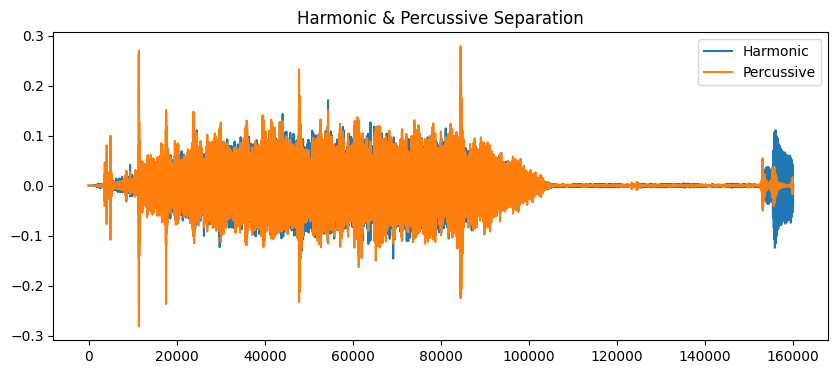

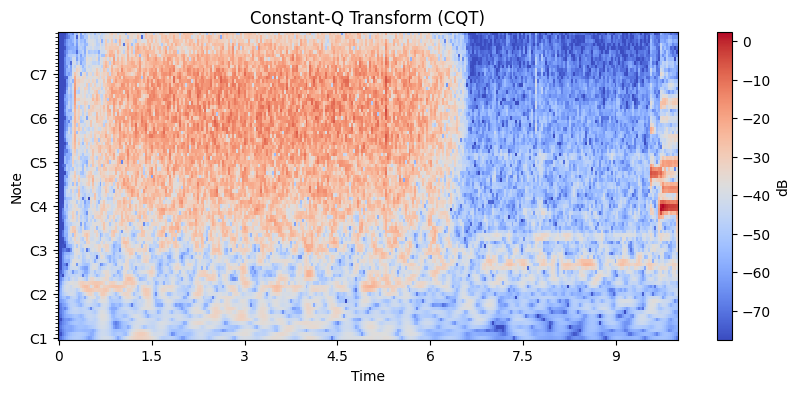

In [9]:
# get audio file by location (see table)
open_audio_file("data_aug2/u3yOMK8SuRI_1.wav")

## Proof of Concept - Simple RNN


### LSTM for Chroma Features


#### Tokenizing


In [10]:
# Preprocessing - Tokenizing
idx_to_chord = list(root_chords)  # mapping of index-to-chords
chord_to_idx = {chord: i for i, chord in enumerate(idx_to_chord)}
print("idx_to_chord:\t", idx_to_chord)
print("chord_to_idx:\t", chord_to_idx)

idx_to_chord:	 ['F#', 'Ebm', 'Dbaug', 'A#', 'A#7', 'Faug', 'Fm7', 'E6', 'Abdim', 'Dm7b5', 'G#6', 'G#m7b5', 'Ab6', 'D#maj7', 'Fm7b5', 'C#aug', 'F#aug', 'G#m', 'Fm', 'Bm7b5', 'A#6', 'Ebmaj7', 'Daug', 'Abmaj7', 'Bdim', 'Gb6', 'C', 'Abm6', 'G#m7', 'Cdim', 'Bbm6', 'Ebm6', 'F#dim', 'Gbdim', 'Dmaj7', 'Abm7', 'C#', 'D#m', 'G6', 'C#m7', 'G#dim', 'Abm7b5', 'Bm', 'Bb', 'F7', 'F#6', 'Bm6', 'Fm6', 'Ebm7', 'C#6', 'F', 'Gm', 'G7', 'A#m', 'F#m', 'Fmaj7', 'Gbm7', 'G#7', 'Fdim', 'Bmaj7', 'F#maj7', 'A6', 'Caug', 'Dbm7b5', 'C#maj7', 'Db6', 'Dbmaj7', 'Cm7b5', 'Bm7', 'Eb', 'Ebdim', 'D#', 'Ebaug', 'Ab', 'Em', 'Bbm', 'G#maj7', 'D6', 'Abaug', 'Dbm6', 'A7', 'F#m6', 'A#m7b5', nan, 'F#m7', 'Cm7', 'Db', 'Gbmaj7', 'F#m7b5', 'Bbm7b5', 'Gbm', 'Ddim', 'D#dim', 'Baug', 'D7', 'C6', 'Abm', 'B6', 'Dbdim', 'C#7', 'A', 'A#aug', 'Am7b5', 'Am', 'G#m6', 'Gm7b5', 'C#m', 'Dm', 'Am6', 'Ebm7b5', 'Eb7', 'C#m7b5', 'C#dim', 'E', 'B7', 'Cmaj7', 'Gm6', 'Bbaug', 'Amaj7', 'E7', 'Bbdim', 'D#6', 'Gmaj7', 'G#aug', 'G', 'Dbm', 'Cm6', 'N', 'B

#### Model Class Definitions


In [56]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps")

def chroma_extraction(file):
    with open(file, "rb") as file_bytes:
        # load and normalize audio file
        audio_data, sr = librosa.load(file, sr=None)
        audio_data = librosa.util.normalize(audio_data)

        # get chroma features (12, T) where T=frames
        chroma_features = librosa.feature.chroma_stft(y=audio_data, sr=sr)
        chroma_features /= np.max(chroma_features)  # scale [0, 1]

        chroma_tensor = torch.tensor(chroma_features, dtype=torch.float32).to(device)
        return chroma_tensor, chroma_tensor.shape[1]  # Shape=(12, sequence_length)

class AudioLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(AudioLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        packed_output, _ = self.lstm(x)  # run LSTM layer
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        return self.fc(output)  # Last time step output
    
class ChromaDataset(TensorDataset):
    def __init__(self, filepaths):
        self.filepaths = filepaths
    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, i):
        filepath = self.filepaths[i]
        chroma_features, seq_len = chroma_extraction(filepath)
        return chroma_features.T, seq_len
    
def collate_fn(batch):
    sequences, lengths = zip(*batch)

    lengths = torch.tensor(lengths, dtype=torch.int64).to(device)

    sorted_indices = torch.argsort(lengths, descending=True)
    sequences = [sequences[i] for i in sorted_indices]
    lengths = lengths[sorted_indices]

    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True).to(device)
    packed_batch = nn.utils.rnn.pack_padded_sequence(padded_sequences, lengths.cpu(), batch_first=True, enforce_sorted=True).to(device)

    return packed_batch, lengths

In [61]:
mock_df = train_df.iloc[0:101]
mock_input_files = "./datashare/" + mock_df["location"]

# Convert chords to vocabulary indices
mock_chords_set = get_chord_set(mock_df['chords'])
mock_chords = get_root_chords(mock_chords_set)
mock_chord_idx = [chord_to_idx[chord] for chord in mock_chords]
mock_outputs = torch.tensor(mock_chord_idx, dtype=torch.long).to(device)

chroma_ds = ChromaDataset(filepaths=mock_input_files)
dataloader = DataLoader(chroma_ds, batch_size=1, shuffle=True, collate_fn=collate_fn)

packed_batch, lengths = next(iter(dataloader))
packed_batch, lengths = packed_batch.to(device), lengths.to(device)
print("Packed batch:", packed_batch)
print("Sequence lengths:", lengths)

Packed batch: PackedSequence(data=tensor([[0.2108, 0.2970, 0.4407,  ..., 0.1091, 0.2108, 0.2684],
        [0.2124, 0.1972, 0.3733,  ..., 0.0668, 0.2036, 0.3841],
        [0.3105, 0.2097, 0.3976,  ..., 0.1097, 0.3085, 0.7202],
        ...,
        [0.7998, 0.2435, 0.0827,  ..., 0.1664, 0.4365, 1.0000],
        [0.4612, 0.2380, 0.4148,  ..., 0.2553, 0.1281, 0.5641],
        [0.1451, 0.0797, 0.4201,  ..., 0.0957, 0.1988, 0.2983]],
       device='mps:0'), batch_sizes=tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [62]:
input_dim = 12  # Chroma feature dimensions (12, 313) --> 12 pitches
hidden_dim = 128  # hyperparameter
output_dim = 172  # Number of Chords: 172
num_layers = 2

lstm_model = AudioLSTM(input_dim, hidden_dim, output_dim, num_layers).to(device)
print(lstm_model)

AudioLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=172, bias=True)
)


In [ ]:
# HYPERPARAMETERS
lr = 0.001
regularization = 0.0001
loss_fn = nn.CrossEntropyLoss().to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=lr, weight_decay=regularization)
epochs = 1

for epoch in range(epochs):
    for batch_idx, (packed_batch, lengths) in enumerate(dataloader):
        packed_batch, lengths = packed_batch.to(device), lengths.to(device)

        opt.zero_grad()

        padded_sequences, _ = nn.utils.rnn.pad_packed_sequence(packed_batch, batch_first=True)
        outputs = lstm_model(packed_batch)
        batch_size = outputs.shape[0]

        # batch_labels = mock_outputs[batch_idx * 2 : batch_idx * 2 + batch_size]
        # if outputs.shape[0] != batch_labels.shape:
        #     print("Output:", outputs.shape, outputs)
        #     print("Actual:", batch_labels.shape, batch_labels)
        #     print("Batch idx:", batch_idx)

        # Create target labels for each time step
        # TODO: figure out batching :/
        batch_labels = []
        for i in range(padded_sequences.shape[0]):
            label = mock_chord_idx[batch_idx * 1 + i]  # Assuming batch_size is 5
            label_seq = torch.full((lengths[i],), label, dtype=torch.long).to(device)
            batch_labels.append(label_seq)

        batch_labels = nn.utils.rnn.pad_sequence(batch_labels, batch_first=True, padding_value=-1).to(device) #padding with -1 so that the loss function ignores them

        # Flatten outputs and labels
        outputs = outputs.view(-1, output_dim)
        batch_labels = batch_labels.view(-1)

        # Calculate loss, ignoring padded time steps
        mask = (batch_labels != -1)
        loss = loss_fn(outputs[mask], batch_labels[mask])

        loss = loss_fn(outputs, batch_labels)

        loss.backward()
        opt.step()
    print(f'Epoch {epoch + 1}, Loss: {loss.item():.7f}')

IndexError: list index out of range

In [55]:
out = lstm_model(next(iter(dataloader))[0])
out_idx = out.argmax(axis=1)
out_chords = [idx_to_chord[i] for i in out_idx]
print("Model output shape:", out.shape)
print("Max classes (indices) per batch:", out_idx)
print("Max classes (chord) per batch:", out_chords, "\n")
print(out)

Model output shape: torch.Size([5, 172])
Max classes (indices) per batch: tensor([3, 3, 3, 3, 3], device='mps:0')
Max classes (chord) per batch: ['A#', 'A#', 'A#', 'A#', 'A#'] 

tensor([[-3.1518e-01, -2.6236e+00, -2.4009e+00,  1.3494e+00,  4.8957e-01,
         -2.6306e+00, -1.9775e+00, -2.0364e+00, -3.0342e+00,  1.6838e-01,
         -2.2512e+00, -2.8899e+00,  9.0803e-02,  1.3042e-01, -2.5517e+00,
         -2.0712e+00, -2.1378e+00,  8.9088e-04,  2.9906e-01, -2.5781e+00,
         -2.7879e+00, -2.4505e+00, -2.2892e+00, -2.7210e+00, -2.0969e+00,
          1.9456e-01,  1.3486e-01, -2.2938e+00, -2.6590e+00, -2.6164e+00,
         -2.4991e+00, -2.6585e+00, -2.4888e+00, -2.4133e+00,  1.4608e-01,
         -2.7491e+00, -2.4385e-02,  1.7473e-01,  6.6363e-01, -5.8742e-01,
         -2.0275e+00, -2.8447e+00, -1.0690e-01, -2.2954e-01, -4.8430e-03,
         -2.0658e+00, -2.0750e+00, -2.9955e+00, -2.7338e+00, -2.1575e+00,
          2.6387e-01, -9.8267e-02, -8.5684e-01, -7.6294e-01, -7.7832e-01,
        